In [1]:
from pylab import *

# MeadowlarkSDK test notebook

Basic interface to the Meadowlark Blink 1920 HDMI SDK via [`meadowlark/MeadowlarkSDK.py`](../meadowlark/MeadowlarkSDK.py).

**Before running:** SLM powered, HDMI + USB connected, secondary monitor enabled in Windows display settings.

**Note:** `Create_SDK()` opens an SDK display window on the SLM monitor. Call `slm.close()` when done, or use the cleanup cell at the bottom.

In [2]:
from pathlib import Path
import sys

# Ensure repo root is on the path (notebook lives in tests/)
repo = Path.cwd()
if not (repo / "meadowlark" / "MeadowlarkSDK.py").exists():
    repo = repo.parent
if not (repo / "meadowlark" / "MeadowlarkSDK.py").exists():
    repo = Path(r"C:\Users\ModeLabQBI\LAB\hardware\SLM")
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

from meadowlark import MeadowlarkSDK, DEFAULT_SDK_PATH

## Configuration

In [3]:
SDK_PATH = DEFAULT_SDK_PATH  # C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK
PIXEL_PITCH_UM = 9.2          # not from SDK — set from datasheet

blink_root = SDK_PATH.parent
LINEAR_LUT = blink_root / "LUT Files" / "1920x1152_linearVoltage.lut"
# Test LUT: every input gray 0–255 -> same drive (1024); mask pattern should not change output
CONSTANT_LUT = blink_root / "LUT Files" / "1920x1152_constantVoltage.lut"

# Optional: path for load_lut test (use CONSTANT_LUT to verify LUT load flattens the panel)
LUT_PATH = None  # e.g. CONSTANT_LUT or LINEAR_LUT

lut_files = sorted(blink_root.rglob("*.lut"))
print(f"SDK path: {SDK_PATH}")
print(f"Linear LUT:  {LINEAR_LUT}")
print(f"Constant LUT (test): {CONSTANT_LUT}")
print(f"Found {len(lut_files)} .lut file(s) under {blink_root}:")
for f in lut_files[:10]:
    print(f"  {f}")
if len(lut_files) > 10:
    print(f"  ... and {len(lut_files) - 10} more")

SDK path: C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK
Linear LUT:  C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\1920x1152_linearVoltage.lut
Constant LUT (test): C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\1920x1152_constantVoltage.lut
Found 2 .lut file(s) under C:\Program Files\Meadowlark Optics\Blink 1920 HDMI:
  C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\1920x1152_constantVoltage.lut
  C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\LUT Files\1920x1152_linearVoltage.lut


## Open SDK

Runs `Create_SDK()`. An SDK window should appear on the SLM HDMI monitor.

In [4]:
from meadowlark import MeadowlarkSDK

In [5]:
# init_sdk=False loads the DLL only; call slm.open() when ready
slm = MeadowlarkSDK()
slm.open()
print(repr(slm))

MeadowlarkSDK(1920x1152, 8-bit, slm_found=True, com_found=True)


In [9]:
ch = 0
slm.set_channel(ch)

In [10]:
slm.get_coverglass_voltage()

6.176000118255615

In [11]:
w, h = slm.width, slm.height

In [14]:
LCOS_buffer = zeros((h,w, 3), uint8)
LCOS_buffer[:,0:w//2, ch] = 100
#slm.write_image(LCOS_buffer)

In [15]:
slm.rgb_buffer[..., 0] = LCOS_buffer[...,1]
slm.write_image()

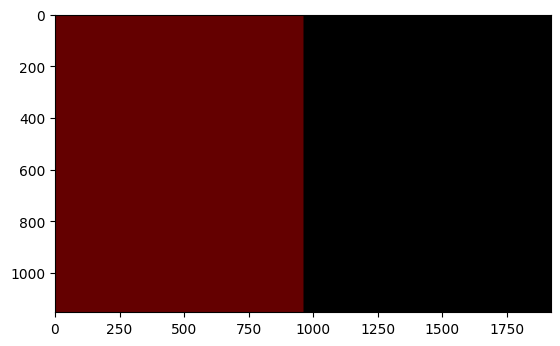

In [16]:
imshow(LCOS_buffer[:,:])

In [14]:
path_to_constant_lut = 'C:\\Program Files\\Meadowlark Optics\\Blink 1920 HDMI\LUT Files\\1920x1152_constantVoltage.lut'
path_to_linear_lut = 'C:\\Program Files\\Meadowlark Optics\\Blink 1920 HDMI\LUT Files\\1920x1152_linearVoltage.lut'

In [40]:
slm.load_lut(path_to_linear_lut)


In [51]:
slm.close()

In [19]:
slm.close()

In [5]:
%gui qt

In [6]:
from ui.meadowlark import MeadowlarkWidget
meadowlark_gui = MeadowlarkWidget()   # no slm, no ModMux
meadowlark_gui.show()

## Geometry and connection status

In [4]:
print(f"resolution (W, H): {slm.resolution}")
print(f"shape (H, W):      {slm.shape}")
print(f"bit depth:         {slm.bit_depth}")
print(f"pixel pitch (µm):  {slm.pixel_pitch}")
print(f"SLM HDMI found:    {slm.slm_found}")
print(f"USB COM found:     {slm.com_found}")

resolution (W, H): (1920, 1152)
shape (H, W):      (1152, 1920)
bit depth:         8
pixel pitch (µm):  (9.2, 9.2)
SLM HDMI found:    True
USB COM found:     True


In [5]:
info = slm.info()
for key, value in info.items():
    print(f"{key:20s} {value}")

resolution           (1920, 1152)
shape                (1152, 1920)
bit_depth            8
pixel_pitch_um       (9.2, 9.2)
slm_found            True
com_found            True
temperature_C        -1.0
coverglass_V         -1.0


## Monitoring (USB)

In [6]:
print(f"Temperature:        {slm.get_temperature():.2f} °C")
print(f"Coverglass voltage: {slm.get_coverglass_voltage():.3f} V")

Temperature:        -1.00 °C
Coverglass voltage: -1.000 V


## Load LUT (optional)

Loads calibration to the SLM controller. Set `LUT_PATH` above, or pick from the list printed in Configuration.

In [ ]:
if LUT_PATH is None and lut_files:
    LUT_PATH = lut_files[0]  # default to first found; change if needed
    print(f"Using first LUT: {LUT_PATH}")

if LUT_PATH is not None:
    slm.load_lut(LUT_PATH)
    print(f"LUT loaded: {LUT_PATH}")
else:
    print("No LUT path set — skipping load_lut")

## HDMI channel

The SLM reads the **red** channel by default (matches writing channel 0 in fullscreenqt).

In [ ]:
slm.set_channel(0)  # 0=red, 1=green, 2=blue
print("HDMI input channel set to red (0)")

## Cleanup

Always call `Delete_SDK()` before exiting — releases the SDK window so your Qt display path can use the monitor.

In [ ]:
slm.close()
print(f"SDK closed (is_open={slm.is_open})")